In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error


In [14]:
df = pd.read_csv("tesla_stock.csv")
print(df.head())

   Unnamed: 0        Date       Open       High        Low      Close  \
0           0  2015-01-02  14.858000  14.883333  14.217333  14.620667   
1           1  2015-01-05  14.303333  14.433333  13.810667  14.006000   
2           2  2015-01-06  14.004000  14.280000  13.614000  14.085333   
3           3  2015-01-07  14.223333  14.318667  13.985333  14.063333   
4           4  2015-01-08  14.187333  14.253333  14.000667  14.041333   

     Volume  
0  71466000  
1  80527500  
2  93928500  
3  44526000  
4  51637500  


In [15]:
#preprocessing
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date',inplace = True)
data = df[['Close']]
data = data.ffill()
print(data.head())

                Close
Date                 
2015-01-02  14.620667
2015-01-05  14.006000
2015-01-06  14.085333
2015-01-07  14.063333
2015-01-08  14.041333


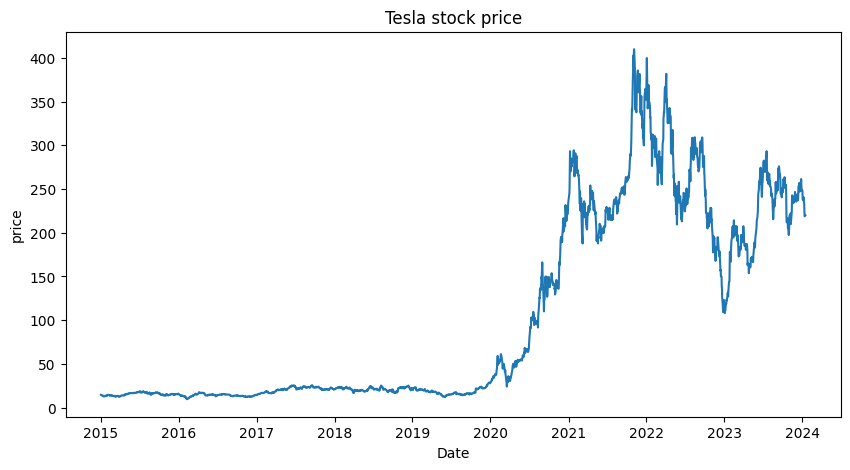

In [16]:
plt.figure(figsize = (10,5))
plt.plot(data['Close'])
plt.title("Tesla stock price")
plt.xlabel("Date")
plt.ylabel("price")
plt.show()

In [17]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

In [18]:
X = []
y = []

for i in range(60, len(scaled_data)):
    X.append(scaled_data[i-60:i])
    y.append(scaled_data[i])

# Convert AFTER loop
X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(2214, 60, 1)
(2214, 1)


In [19]:
split = int(0.8 * len(X))

X_train = X[:split]
X_test = X[split:]
y_train = y[:split]
y_test = y[split:]

In [9]:
model = LinearRegression()

X_train = X_train.reshape(X_train.shape[0], -1)

model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [10]:
X_test = X_test.reshape(X_test.shape[0], -1)

predictions = model.predict(X_test)

# Convert back
predictions = scaler.inverse_transform(predictions)
y_test_actual = scaler.inverse_transform(y_test)

Mean Squared Error: 81.85394868435276


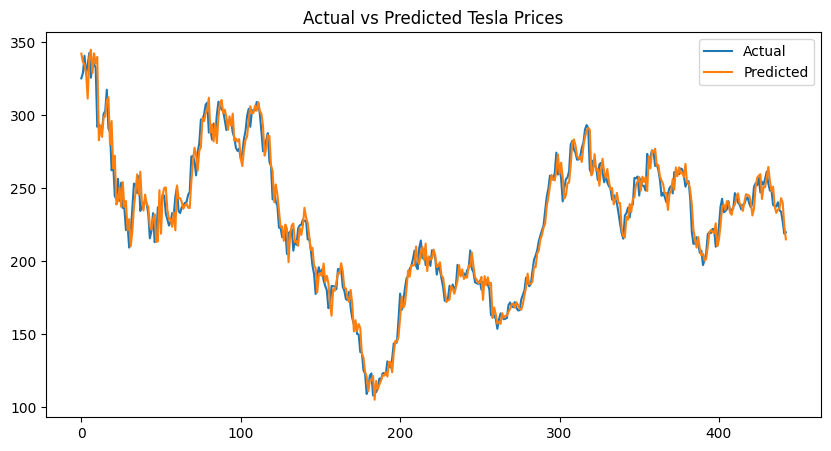

In [11]:
mse = mean_squared_error(y_test_actual, predictions)
print("Mean Squared Error:", mse)

plt.figure(figsize=(10,5))
plt.plot(y_test_actual, label="Actual")
plt.plot(predictions, label="Predicted")
plt.legend()
plt.title("Actual vs Predicted Tesla Prices")
plt.show()

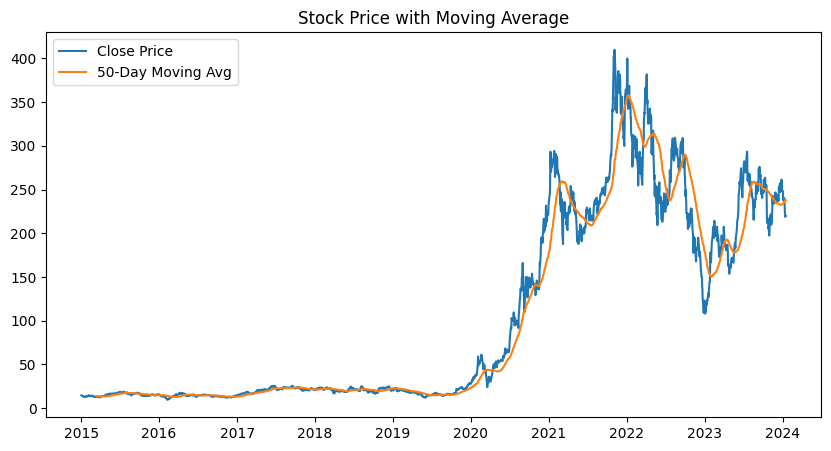

In [12]:
data['MA50'] = data['Close'].rolling(window=50).mean()

plt.figure(figsize=(10,5))
plt.plot(data['Close'], label='Close Price')
plt.plot(data['MA50'], label='50-Day Moving Avg')
plt.legend()
plt.title("Stock Price with Moving Average")
plt.show()

In [20]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test_actual, predictions)
print("R2 Score:", r2)

R2 Score: 0.9638528796934721


In [21]:
last_60_days = scaled_data[-60:]
last_60_days = last_60_days.reshape(1, -1)

next_day = model.predict(last_60_days)
next_day = scaler.inverse_transform(next_day)

print("Next Day Predicted Price:", next_day[0][0])

Next Day Predicted Price: 216.40541808567002


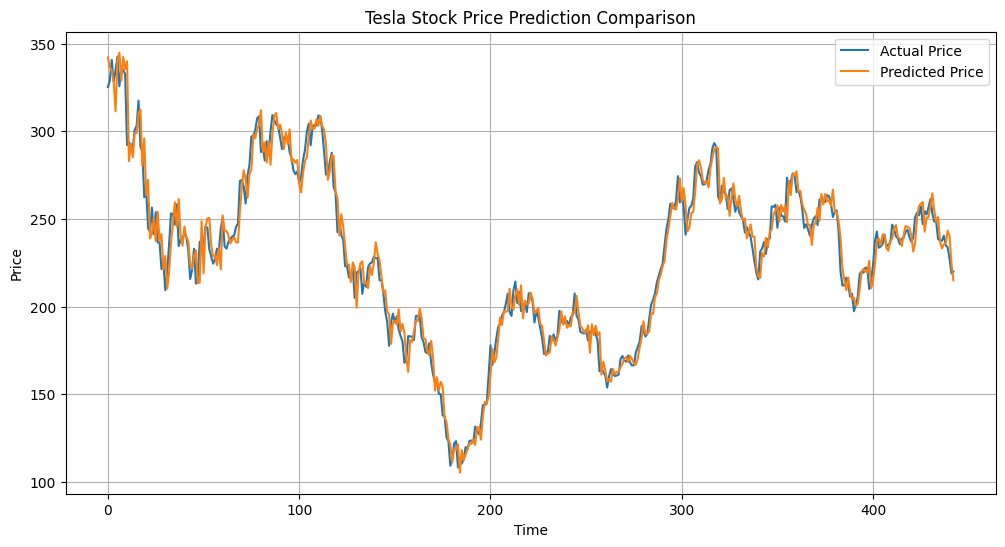

In [22]:
plt.figure(figsize=(12,6))
plt.plot(y_test_actual, label="Actual Price")
plt.plot(predictions, label="Predicted Price")
plt.legend()
plt.title("Tesla Stock Price Prediction Comparison")
plt.xlabel("Time")
plt.ylabel("Price")
plt.grid()
plt.show()